In [1]:
import pathlib
import tarfile
import yaml

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

from plot_utils import annotate_ax_with_correlations as annotate_facet_with_correlations

In [2]:
!ls /mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_rep_1/ | wc -l

5187


In [7]:
def load_results_from_directory(load_dir):
    results = {}
    for filename in pathlib.Path(load_dir).glob("*.tar.gz"):
        try:
            with tarfile.open(filename, "r:gz") as tar:
                with tar.extractfile("./info.yaml") as fh:
                    ret = yaml.safe_load(fh)
                    results[ret["variant"]] = {
                        'interface_delta_X':ret["results"]["best_struct_interface_delta_X"],
                        'total_energy':ret["results"]["best_struct_total_energy"]
                                          }
        except: # ignore all errors
            pass
        #break
    results_df = pd.DataFrame.from_dict(results, orient="index")
    return results_df

In [4]:
load_dir = "/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_onerelax_rep_1"
save_filename = "../data/rosetta/andres_temp_5_onerelax_rep_1.csv"
if not pathlib.Path(save_filename).exists():
    results_df = load_results_from_directory(load_dir)
    results_df.to_csv(save_filename, index=True, index_label="variant")
andres_temp_5_rep_1_df = pd.read_csv(save_filename)

In [8]:
load_dir = "/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_onerelax_rep_2"
save_filename = "../data/rosetta/andres_temp_5_onerelax_rep_2.csv"
if not pathlib.Path(save_filename).exists():
    results_df = load_results_from_directory(load_dir)
    results_df.to_csv(save_filename, index=True, index_label="variant")
andres_temp_5_rep_2_df = pd.read_csv(save_filename)

In [9]:
#andres_temp_5_rep_1_df

In [10]:
df = pd.merge(andres_temp_5_rep_1_df,andres_temp_5_rep_2_df, on="variant")
df

,variant,interface_delta_X_x,total_energy_x,interface_delta_X_y,total_energy_y
0,D158S,-17.124,-869.020,-17.176,-869.223
1,Q236D,-17.693,-876.090,-17.766,-874.692
2,Q177L,-18.727,-873.171,-17.596,-870.630
3,A50P,-18.008,-873.015,-17.897,-874.056
4,Q185G,-17.652,-875.726,-17.642,-872.951
...,...,...,...,...,...
3880,V133L,-17.926,-878.732,-17.754,-878.497
3881,I263F,-17.648,-871.675,-17.681,-872.381
3882,A37Y,-17.895,-863.203,-17.834,-871.357
3883,R255C,-15.936,-870.314,-15.114,-871.464


In [11]:
print("Number of missing entries : ", df.isna().any(axis=1).sum())

Number of missing entries :  52


In [12]:
df = df[~df.isna().any(axis=1)].copy()

In [13]:
spearmanr(df.interface_delta_X_x, df.interface_delta_X_y, nan_policy="omit")

SignificanceResult(statistic=0.5129240317365844, pvalue=2.6981467146864744e-256)

In [14]:
pearsonr(df.interface_delta_X_x, df.interface_delta_X_y)

PearsonRResult(statistic=0.7900311498030476, pvalue=0.0)

In [15]:
spearmanr(df.total_energy_x, df.total_energy_y, nan_policy="omit")

SignificanceResult(statistic=0.7328271536809896, pvalue=0.0)

In [16]:
pearsonr(df.total_energy_x, df.total_energy_y)

PearsonRResult(statistic=0.9822396743588274, pvalue=0.0)

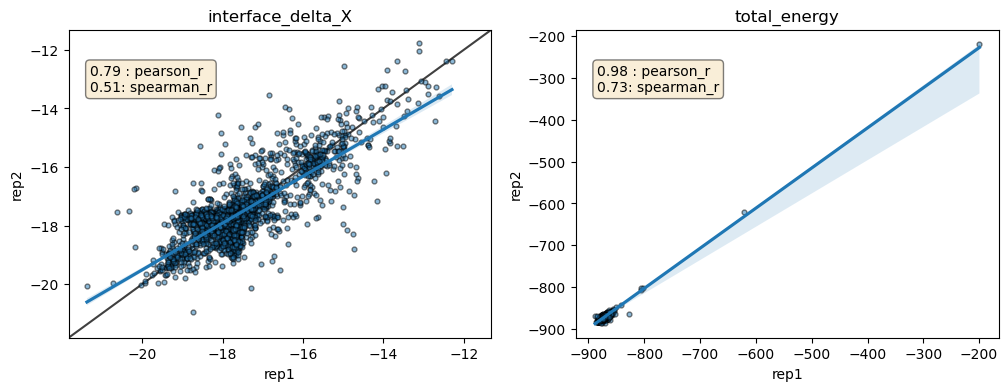

In [17]:
nrows=1
col_wrap=2
scatter_kws={'s':12, 'edgecolor':'k', 'alpha':0.5}

fig, axs = plt.subplots(nrows=nrows, ncols=col_wrap, figsize=(6*col_wrap, 4*nrows))

ax = axs[0]
sns.regplot(x=df.interface_delta_X_x, y=df.interface_delta_X_y, ax=ax,
                       scatter_kws=scatter_kws)
ax.set_xlabel("rep1")
ax.set_ylabel("rep2")
ax.set_title("interface_delta_X")
annotate_facet_with_correlations(x=df.interface_delta_X_x,  
                                 y=df.interface_delta_X_y,
                                             ax=ax)

# from https://stackoverflow.com/questions/25497402/adding-y-x-to-a-matplotlib-scatter-plot-if-i-havent-kept-track-of-all-the-data
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
#ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax = axs[1]
sns.regplot(x=df.total_energy_x, y=df.total_energy_y, ax=ax,
                       scatter_kws=scatter_kws)
ax.set_xlabel("rep1")
ax.set_ylabel("rep2")
ax.set_title("total_energy")
annotate_facet_with_correlations(x=df.total_energy_x,  
                                 y=df.total_energy_y,
                                             ax=ax)




pass

In [18]:
# take rep1 and make a mutation map
mut_df = df[['variant', 'interface_delta_X_x']].copy()
mut_df["mut_aa"] = mut_df.variant.str.get(-1)
mut_df["mut_pos"] = mut_df.variant.str.slice(1, -1).astype(int)
mut_df

,variant,interface_delta_X_x,mut_aa,mut_pos
0,D158S,-17.124,S,158
1,Q236D,-17.693,D,236
2,Q177L,-18.727,L,177
3,A50P,-18.008,P,50
4,Q185G,-17.652,G,185
...,...,...,...,...
3880,V133L,-17.926,L,133
3881,I263F,-17.648,F,263
3882,A37Y,-17.895,Y,37
3883,R255C,-15.936,C,255


<AxesSubplot: xlabel='interface_delta_X_x', ylabel='Count'>

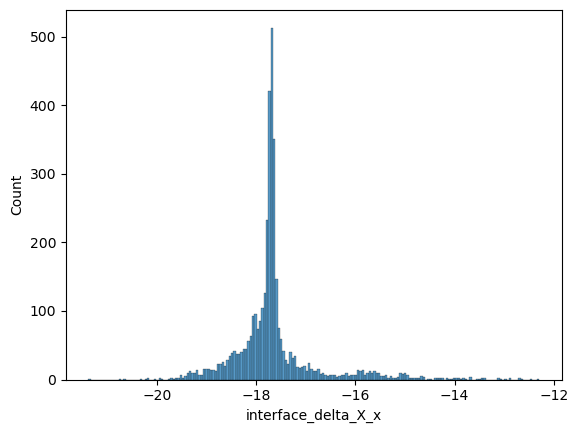

In [19]:
sns.histplot(mut_df.interface_delta_X_x)

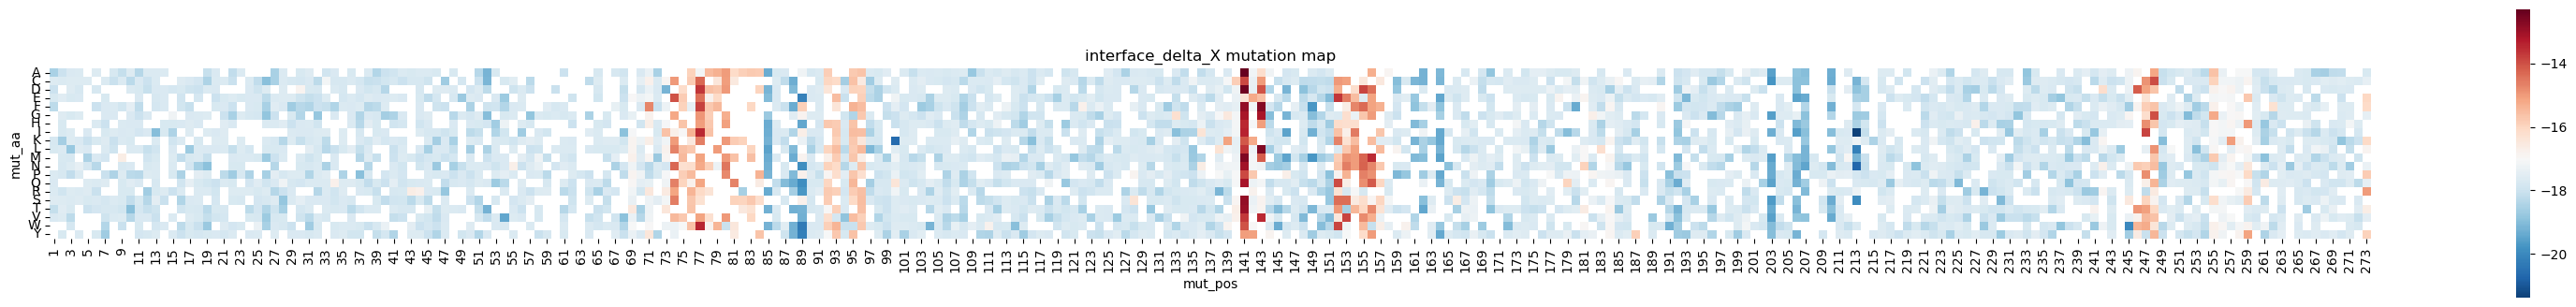

In [20]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(mut_df.pivot(index="mut_aa", columns="mut_pos", values="interface_delta_X_x"), 
                  center = -17, cmap = 'RdBu_r', square = True)
plt.title("interface_delta_X mutation map")
plt.savefig("../output/rosetta_redo_with_onerelax.png", dpi=300)
pass